### P-median

In this section, we formulate the p-median problem. We define the following additional input parameters:  
$p$, the number of facilities to be located; $d_j$, the demand of customer $j$; and $c_{ij}$, the cost or weight of serving customer $j$ from facility $i$.

Finally, we define the following decision variables:

$$
y_i =
\begin{cases}
1 & \text{if a facility is located at candidate site } i, \\
0 & \text{otherwise,}
\end{cases}
$$

and $x_{ij}$, the fraction of customer $j$'s demand that is supplied from facility $i$.

With this notation, we can formulate the p-median problem as follows:

$$
\begin{aligned}
\text{min} \quad & \sum_{i \in I} \sum_{j \in J} d_j c_{ij} x_{ij} \\
\text{subject to} \quad & \sum_{i \in I} x_{ij} = 1 \quad \forall j \in J \\
& \sum_{i \in I} y_i = p \\
& x_{ij} - y_i \leq 0 \quad \forall i \in I,\; j \in J \\
& y_i \in \{0, 1\} \quad \forall i \in I \\
& x_{ij} \geq 0 \quad \forall i \in I,\; j \in J
\end{aligned}
$$

In [2]:
%pip install gurobipy
from gurobipy import Model, GRB, quicksum
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 42.6 MB/s eta 0:00:00


In [3]:
# Number of candidate facility sites
num_facilities = 5

# Number of customers
num_customers = 5

# Sets
I = range(num_facilities)
J = range(num_customers)

# Symmetric service cost matrix
c = np.array([[0, 3, 3, 6, 3],
              [3, 0, 4, 5, 5],
              [3, 4, 0, 2, 4],
              [6, 5, 2, 0, 5],
              [3, 5, 4, 5, 0]])

# Customer demand
d = np.array([10, 8, 5, 8, 12])

# Number of facilities to locate
p = 2

In [4]:
# Define model
m = Model("p-median")

# Decision variables
x = m.addVars(I, J, vtype=GRB.CONTINUOUS, name="x")
y = m.addVars(I, vtype=GRB.BINARY, name="y")

# Objective function
m.setObjective(quicksum(d[j] * c[i, j] * x[i, j] for i in I for j in J), GRB.MINIMIZE)

# Constraints
m.addConstrs(quicksum(x[i, j] for i in I) == 1 for j in J)
m.addConstr(quicksum(y[i] for i in I) == p)
m.addConstrs(x[i, j] - y[i] <= 0 for i in I for j in J)

# Optimize
m.optimize()

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 31 rows, 30 columns and 80 nonzeros (Min)
Model fingerprint: 0x5a0a8248
Model has 20 linear objective coefficients
Variable types: 25 continuous, 5 integer (5 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+01, 6e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+00]

Presolve time: 0.00s
Presolved: 31 rows, 30 columns, 80 nonzeros
Variable types: 25 continuous, 5 integer (5 binary)
Found heuristic solution: objective 91.0000000
Found heuristic solution: objective 80.0000000

Root relaxation: objective 7.000000e+01, 11 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objec

In [6]:
if m.status == GRB.OPTIMAL:
    print("Optimal solution")
    print("Total cost: ", m.objVal)
    for i in I:
      if y[i].X > 0.1:
          print("Open facility: ", i)
else:
    print("There is not optimal solution")

Optimal solution
Total cost:  70.0
Open facility:  0
Open facility:  3


In [7]:
import matplotlib.pyplot as plt

def solve_and_plot_p_median(num_facilities=5, num_customers=5, p=2, seed=42,
                            coord_range=(0, 100), metric="euclidean"):

    rng = np.random.default_rng(seed)

    I = range(num_facilities)
    J = range(num_customers)

    facilities_xy = rng.uniform(coord_range[0], coord_range[1], size=(num_facilities, 2))
    customers_xy = rng.uniform(coord_range[0], coord_range[1], size=(num_customers, 2))

    if metric.lower() == "euclidean":
        # c[i,j] = ||facility_i - customer_j||_2
        diff = facilities_xy[:, None, :] - customers_xy[None, :, :]
        c = np.sqrt((diff ** 2).sum(axis=2))
    elif metric.lower() == "manhattan":
        diff = np.abs(facilities_xy[:, None, :] - customers_xy[None, :, :])
        c = diff.sum(axis=2)
    else:
        raise ValueError("metric must be 'euclidean' or 'manhattan'")

    m = Model("p-median")
    x = m.addVars(I, J, vtype=GRB.CONTINUOUS, lb=0.0, ub=1.0, name="x")
    y = m.addVars(I, vtype=GRB.BINARY, name="y")

    m.setObjective(quicksum(c[i, j] * x[i, j] for i in I for j in J), GRB.MINIMIZE)
    m.addConstrs((quicksum(x[i, j] for i in I) == 1 for j in J))
    m.addConstr(quicksum(y[i] for i in I) == p)
    m.addConstrs((x[i, j] <= y[i] for i in I for j in J))

    m.optimize()

    min_dist = float("inf")
    max_dist = 0.0

    open_facilities = [i for i in I if y[i].X > 0.5]
    assignments = {}  # j -> i (assigned facility)
    for j in J:
        # Since this is an LP assignment, take the argmax of x[i,j]
        i_star = max(I, key=lambda i: x[i, j].X)
        assignments[j] = i_star
        dist = float(c[i_star, j])
        min_dist = min(min_dist, dist)
        max_dist = max(max_dist, dist)

    print(f"Minimum distance traveled by a customer: {min_dist:.4f}")
    print(f"Maximum distance traveled by a customer: {max_dist:.4f}")
    for i in open_facilities:
        print("Open facility at:", i)

    plt.figure(figsize=(9, 7))

    # Customers
    plt.scatter(customers_xy[:, 0], customers_xy[:, 1], marker="o")
    for j in J:
        plt.annotate(f"C{j}", (customers_xy[j, 0], customers_xy[j, 1]), xytext=(5, 5),
                     textcoords="offset points")

    # Closed facilities
    closed_facilities = [i for i in I if i not in open_facilities]
    if closed_facilities:
        plt.scatter(facilities_xy[closed_facilities, 0], facilities_xy[closed_facilities, 1], marker="s")
        for i in closed_facilities:
            plt.annotate(f"F{i}", (facilities_xy[i, 0], facilities_xy[i, 1]), xytext=(5, 5),
                         textcoords="offset points")

    # Open facilities (highlighted)
    if open_facilities:
        plt.scatter(facilities_xy[open_facilities, 0], facilities_xy[open_facilities, 1], marker="s")
        for i in open_facilities:
            plt.annotate(f"F{i}*", (facilities_xy[i, 0], facilities_xy[i, 1]), xytext=(5, 5),
                         textcoords="offset points")

    # Assignment lines
    for j, i in assignments.items():
        x0, y0 = customers_xy[j, 0], customers_xy[j, 1]
        x1, y1 = facilities_xy[i, 0], facilities_xy[i, 1]
        plt.plot([x0, x1], [y0, y1], linewidth=1)

    plt.title(f"p-median solution (p={p}) in 2D - metric: {metric}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return m

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 391 rows, 372 columns and 1092 nonzeros (Min)
Model fingerprint: 0x859a0648
Model has 360 linear objective coefficients
Variable types: 360 continuous, 12 integer (12 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [6e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+00]

Presolve time: 0.00s
Presolved: 391 rows, 372 columns, 1092 nonzeros
Variable types: 360 continuous, 12 integer (12 binary)
Found heuristic solution: objective 967.9034967
Found heuristic solution: objective 803.0939514

Root relaxation: objective 5.747302e+02, 75 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Dept

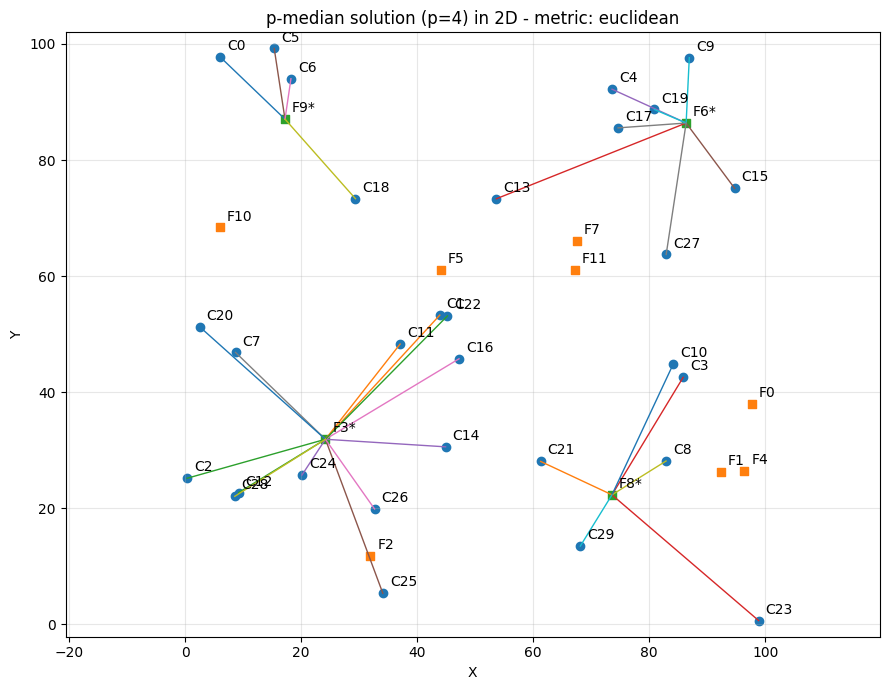

<gurobi.Model MIP instance p-median: 391 constrs, 372 vars, No parameter changes>

In [ ]:
solve_and_plot_p_median(num_facilities=12, num_customers=30, p = 4 , seed=1234, metric="euclidean")